<a href="https://colab.research.google.com/github/sanskrutimishra2307-droid/Machine_Vision_Lab/blob/main/MV03_016.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload Reference Image and Test Image


Saving stop_test.png to stop_test (2).png
Using uploaded file 'stop_test (2).png' as reference image.
Using existing file 'stop_test.png' as test image.
Both reference and test images loaded successfully.


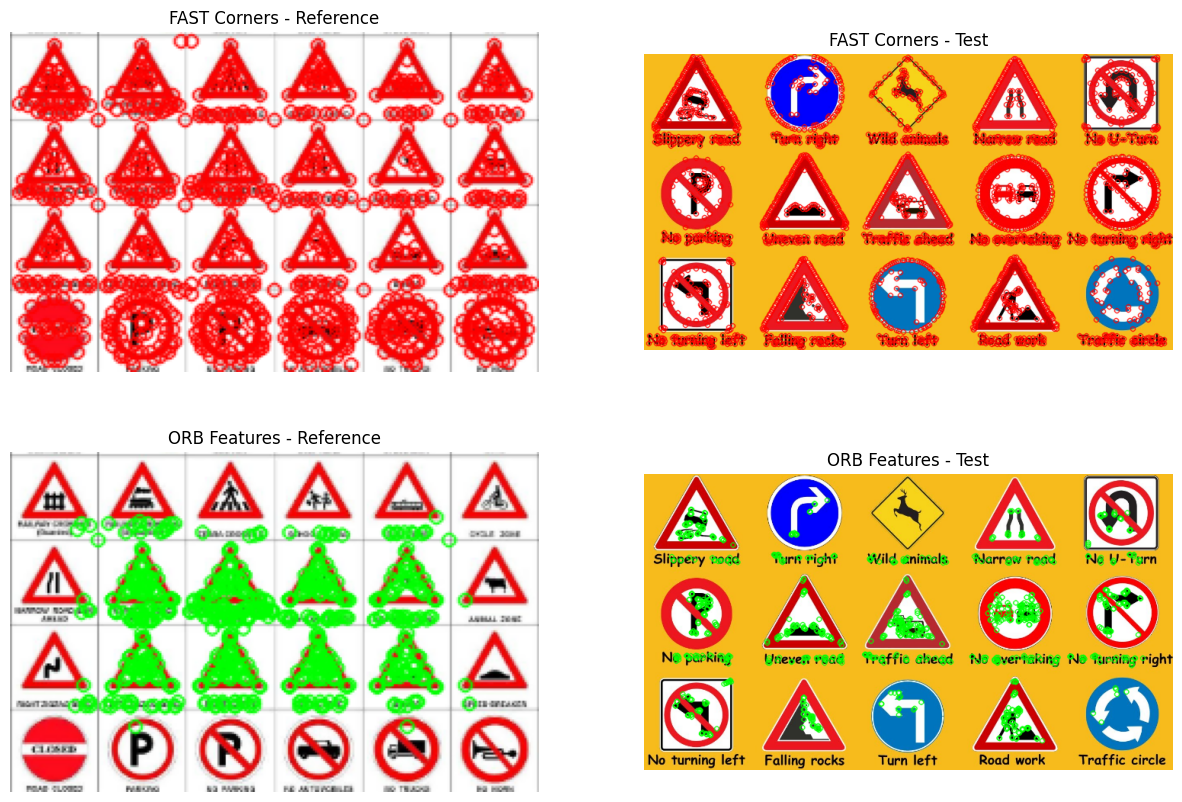

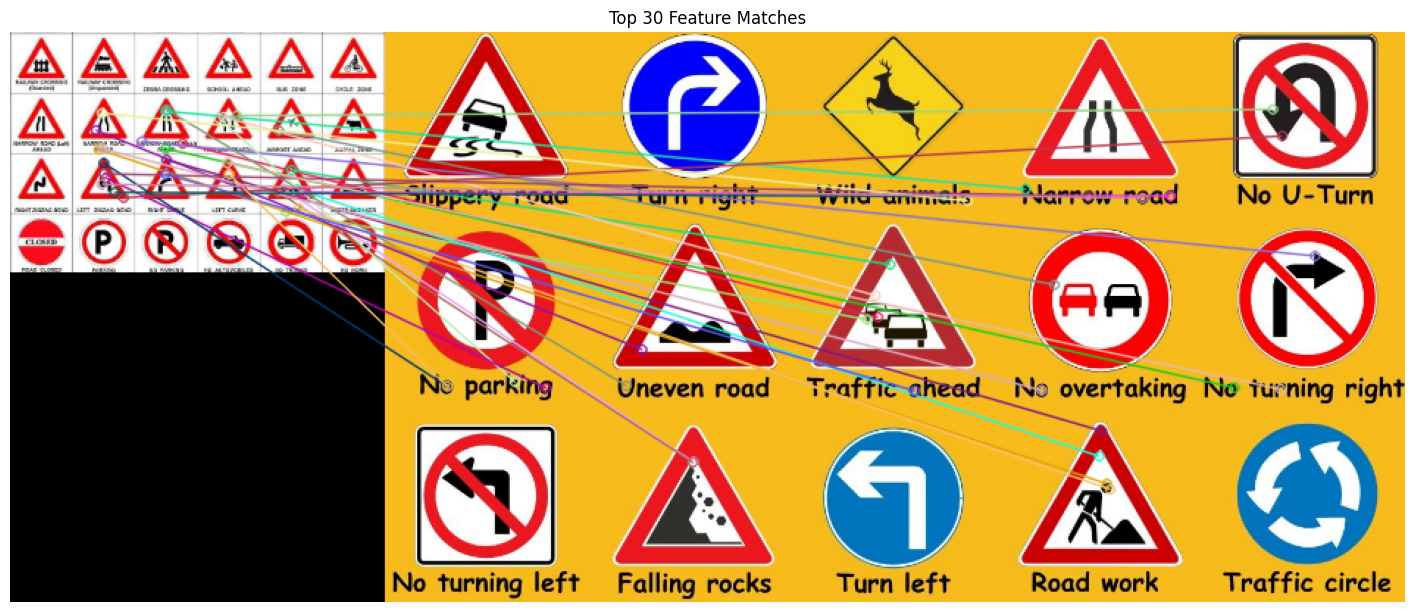

FAST Corner Detection
Reference Corners : 869
Test Corners      : 2469

ORB Feature Extraction
Reference Keypoints : 668
Test Keypoints      : 1000

Feature Matching
Total Matches : 176
Good Matches  : 9

Recognition Score : 1.35%

Road Sign Not Recognized


In [ ]:
# ============================================================
# Road Sign Recognition using FAST, ORB and BRIEF (Google Colab)
# ============================================================

# Install OpenCV Contrib
!pip install -q opencv-contrib-python

# Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import sys # Import sys for sys.exit()
import os # Import os for listing directory contents

# -----------------------------
# Upload Images
# -----------------------------
print("Upload Reference Image and Test Image")
uploaded = files.upload()

# Determine reference and test image paths from uploaded files or existing in content
reference_path = None
test_path = None

# Get the list of files in the current directory after upload
current_files = os.listdir('.')

# Get the first uploaded file from the current upload for the reference image
if uploaded:
    reference_path = list(uploaded.keys())[0]
    print(f"Using uploaded file '{reference_path}' as reference image.")
else:
    print("Warning: No file was uploaded in this step for the reference image.")
    # Try to find a known reference image from previous uploads if not newly uploaded
    if "stop_reference (1).png" in current_files:
        reference_path = "stop_reference (1).png"
        print(f"Using previously uploaded file '{reference_path}' as reference image.")
    elif "stop_reference.png" in current_files:
        reference_path = "stop_reference.png"
        print(f"Using previously uploaded file '{reference_path}' as reference image.")
    elif "Screenshot 2026-07-07 115307.png" in current_files:
        reference_path = "Screenshot 2026-07-07 115307.png"
        print(f"Using previously uploaded file '{reference_path}' as reference image.")

# Explicitly look for 'stop_test.png' as the test image (assuming it was previously uploaded)
if "stop_test.png" in current_files:
    test_path = "stop_test.png"
    print(f"Using existing file '{test_path}' as test image.")
elif "stop_test (1).png" in current_files: # Check for renamed versions too
    test_path = "stop_test (1).png"
    print(f"Using existing file '{test_path}' as test image.")
else:
    print("Warning: 'stop_test.png' or a similar test image was not found in the content directory.")
    # If the test image was part of the current upload and not the reference
    if uploaded and len(uploaded.keys()) > 1 and list(uploaded.keys())[0] != reference_path:
        test_path = list(uploaded.keys())[1]
        print(f"Using second uploaded file '{test_path}' as test image.")

# -----------------------------
# Read Images
# -----------------------------
reference = None
test = None
images_loaded = False

if reference_path:
    reference = cv2.imread(reference_path)

if test_path:
    test = cv2.imread(test_path)

if reference is None:
    print(f"Error: Could not load reference image from '{reference_path}'. Please ensure the file exists and is a valid image.")
if test is None:
    print(f"Error: Could not load test image from '{test_path}'. Please ensure the file exists and is a valid image.")

# Proceed only if both images are loaded successfully
if reference is not None and test is not None:
    print("Both reference and test images loaded successfully.")
    reference_rgb = cv2.cvtColor(reference, cv2.COLOR_BGR2RGB)
    test_rgb = cv2.cvtColor(test, cv2.COLOR_BGR2RGB)

    reference_gray = cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY)
    test_gray = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)
    images_loaded = True
else:
    print("Image loading failed. Skipping feature detection and matching steps.")
    # To prevent further errors, set placeholder variables to None
    reference_rgb, test_rgb, reference_gray, test_gray = None, None, None, None

# All subsequent image processing and display code will be wrapped in this 'if' block
if images_loaded:
    # -----------------------------
    # FAST Corner Detection
    # -----------------------------
    fast = cv2.FastFeatureDetector_create()

    fast_kp_ref = fast.detect(reference_gray, None)
    fast_kp_test = fast.detect(test_gray, None)

    fast_ref_img = cv2.drawKeypoints(reference_rgb, fast_kp_ref, None, color=(255,0,0))
    fast_test_img = cv2.drawKeypoints(test_rgb, fast_kp_test, None, color=(255,0,0))

    # -----------------------------
    # ORB Feature Detection + BRIEF Descriptor
    # -----------------------------
    orb = cv2.ORB_create(nfeatures=1000)

    kp1, des1 = orb.detectAndCompute(reference_gray, None)
    kp2, des2 = orb.detectAndCompute(test_gray, None)

    orb_ref = cv2.drawKeypoints(reference_rgb, kp1, None, color=(0,255,0))
    orb_test = cv2.drawKeypoints(test_rgb, kp2, None, color=(0,255,0))

    # -----------------------------
    # Feature Matching
    # -----------------------------
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    # Good Matches
    good_matches = [m for m in matches if m.distance < 50]

    # Draw Best Matches
    matched_img = cv2.drawMatches(
        reference_rgb,
        kp1,
        test_rgb,
        kp2,
        matches[:30],
        None,
        flags=2
    )

    # -----------------------------
    # Recognition Score
    # -----------------------------
    # Avoid division by zero if no keypoints were found in reference
    recognition_score = (len(good_matches) / len(kp1)) * 100 if len(kp1) > 0 else 0

    # -----------------------------
    # Display Results
    # -----------------------------
    plt.figure(figsize=(15,10))

    plt.subplot(2,2,1)
    plt.imshow(fast_ref_img)
    plt.title("FAST Corners - Reference")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(fast_test_img)
    plt.title("FAST Corners - Test")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(orb_ref)
    plt.title("ORB Features - Reference")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(orb_test)
    plt.title("ORB Features - Test")
    plt.axis("off")

    plt.show()

    plt.figure(figsize=(18,8))
    plt.imshow(matched_img)
    plt.title("Top 30 Feature Matches")
    plt.axis("off")
    plt.show()

    # -----------------------------
    # Print Results
    # -----------------------------
    print("="*50)
    print("FAST Corner Detection")
    print("="*50)
    print("Reference Corners :", len(fast_kp_ref))
    print("Test Corners      :", len(fast_kp_test))

    print("\n" + "="*50)
    print("ORB Feature Extraction")
    print("="*50)
    print("Reference Keypoints :", len(kp1))
    print("Test Keypoints      :", len(kp2))

    print("\n" + "="*50)
    print("Feature Matching")
    print("="*50)
    print("Total Matches :", len(matches))
    print("Good Matches  :", len(good_matches))

    print("\nRecognition Score : {:.2f}%".format(recognition_score))

    # Decision
    if len(good_matches) > 20:
        print("\nRoad Sign Recognized")
    else:
        print("\nRoad Sign Not Recognized")
